In [80]:
from math import sqrt
from numpy import concatenate
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM , Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
import tensorflow as tf
import plotly.offline as py
import plotly.graph_objs as go
import numpy as np
import seaborn as sns
py.init_notebook_mode(connected=True)
%matplotlib inline

In [81]:
data = pd.read_csv("btcusdt_1h.csv")
data['datetime'] = pd.to_datetime(data['datetime'])
data['signal'] = np.where(data['close'].shift(1) > data['close'], 1, -1)
data.dropna()
data


,datetime,open,high,low,close,volume,signal
0,2018-01-01 05:30:00,13715.65,13715.65,13400.01,13529.01,443.356199,-1
1,2018-01-01 06:30:00,13528.99,13595.89,13155.38,13203.06,383.697006,1
2,2018-01-01 07:30:00,13203.00,13418.43,13200.00,13330.18,429.064572,-1
3,2018-01-01 08:30:00,13330.26,13611.27,13290.00,13410.03,420.087030,-1
4,2018-01-01 09:30:00,13434.98,13623.29,13322.15,13601.01,340.807329,-1
...,...,...,...,...,...,...,...
35203,2022-01-12 01:30:00,42972.04,43095.26,42692.19,42800.38,1219.601780,1
35204,2022-01-12 02:30:00,42797.62,42823.69,42643.74,42659.20,702.103800,1
35205,2022-01-12 03:30:00,42664.71,42776.14,42597.41,42713.13,561.859930,-1
35206,2022-01-12 04:30:00,42713.12,42886.28,42633.97,42729.29,681.142010,-1


In [82]:
# flag = 0
# for i in range(len(data['signal'])):
#     if flag == 0:
#         flag = data['signal'].loc[i]
#     elif flag == data['signal'].loc[i] :
#         data['signal'][i] = 0
#     elif flag == -data['signal'].loc[i]:
#         flag = 0
#     if i == len(data['signal']) - 1:
#         data['signal'].loc[i] = -flag
# print(data['signal'])

In [83]:
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = 1 if type(data) is list else data.shape[1]
    df = pd.DataFrame(data)
    cols, names = list(), list()
    # input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    # forecast sequence (t, t+1, ... t+n)
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
    # put it all together
    agg = pd.concat(cols, axis=1)
    agg.columns = names
    # drop rows with NaN values
    if dropnan:
        agg.dropna(inplace=True)
    return agg

In [84]:
values = data[['close'] + ['volume'] ].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(values)
scaled

array([[0.15821418, 0.00938206],
       [0.15323493, 0.00811958],
       [0.15517683, 0.00907962],
       ...,
       [0.60403436, 0.01188977],
       [0.60428122, 0.01441395],
       [0.60345188, 0.02126528]])

In [85]:
reframed = series_to_supervised(scaled, 12, 1)
reframed.head()

,var1(t-12),var2(t-12),var1(t-11),var2(t-11),var1(t-10),var2(t-10),var1(t-9),var2(t-9),var1(t-8),var2(t-8),...,var1(t-4),var2(t-4),var1(t-3),var2(t-3),var1(t-2),var2(t-2),var1(t-1),var2(t-1),var1(t),var2(t)
12,0.158214,0.009382,0.153235,0.008120,0.155177,0.009080,0.156397,0.008890,0.159314,0.007212,...,0.157771,0.005752,0.159558,0.004509,0.158841,0.003587,0.153502,0.014079,0.152767,0.005512
13,0.153235,0.008120,0.155177,0.009080,0.156397,0.008890,0.159314,0.007212,0.158672,0.008554,...,0.159558,0.004509,0.158841,0.003587,0.153502,0.014079,0.152767,0.005512,0.150393,0.009563
14,0.155177,0.009080,0.156397,0.008890,0.159314,0.007212,0.158672,0.008554,0.162055,0.005608,...,0.158841,0.003587,0.153502,0.014079,0.152767,0.005512,0.150393,0.009563,0.153362,0.014654
15,0.156397,0.008890,0.159314,0.007212,0.158672,0.008554,0.162055,0.005608,0.158846,0.006183,...,0.153502,0.014079,0.152767,0.005512,0.150393,0.009563,0.153362,0.014654,0.153906,0.009037
16,0.159314,0.007212,0.158672,0.008554,0.162055,0.005608,0.158846,0.006183,0.157771,0.005752,...,0.152767,0.005512,0.150393,0.009563,0.153362,0.014654,0.153906,0.009037,0.150408,0.007775


In [86]:
reframed.drop(reframed.columns[[24,25]], axis=1, inplace=True)
print(reframed)

       var1(t-12)  var2(t-12)  var1(t-11)  var2(t-11)  var1(t-10)  var2(t-10)   
12       0.158214    0.009382    0.153235    0.008120    0.155177    0.009080  \
13       0.153235    0.008120    0.155177    0.009080    0.156397    0.008890   
14       0.155177    0.009080    0.156397    0.008890    0.159314    0.007212   
15       0.156397    0.008890    0.159314    0.007212    0.158672    0.008554   
16       0.159314    0.007212    0.158672    0.008554    0.162055    0.005608   
...           ...         ...         ...         ...         ...         ...   
35203    0.593015    0.046506    0.592908    0.022409    0.587504    0.032693   
35204    0.592908    0.022409    0.587504    0.032693    0.590238    0.026898   
35205    0.587504    0.032693    0.590238    0.026898    0.590279    0.020038   
35206    0.590238    0.026898    0.590279    0.020038    0.588581    0.024630   
35207    0.590279    0.020038    0.588581    0.024630    0.587672    0.047856   

       var1(t-9)  var2(t-9)

In [87]:
reframed['target'] = data['signal'].iloc[12:]
reframed.head()

,var1(t-12),var2(t-12),var1(t-11),var2(t-11),var1(t-10),var2(t-10),var1(t-9),var2(t-9),var1(t-8),var2(t-8),...,var2(t-5),var1(t-4),var2(t-4),var1(t-3),var2(t-3),var1(t-2),var2(t-2),var1(t-1),var2(t-1),target
12,0.158214,0.009382,0.153235,0.008120,0.155177,0.009080,0.156397,0.008890,0.159314,0.007212,...,0.006183,0.157771,0.005752,0.159558,0.004509,0.158841,0.003587,0.153502,0.014079,1
13,0.153235,0.008120,0.155177,0.009080,0.156397,0.008890,0.159314,0.007212,0.158672,0.008554,...,0.005752,0.159558,0.004509,0.158841,0.003587,0.153502,0.014079,0.152767,0.005512,1
14,0.155177,0.009080,0.156397,0.008890,0.159314,0.007212,0.158672,0.008554,0.162055,0.005608,...,0.004509,0.158841,0.003587,0.153502,0.014079,0.152767,0.005512,0.150393,0.009563,-1
15,0.156397,0.008890,0.159314,0.007212,0.158672,0.008554,0.162055,0.005608,0.158846,0.006183,...,0.003587,0.153502,0.014079,0.152767,0.005512,0.150393,0.009563,0.153362,0.014654,-1
16,0.159314,0.007212,0.158672,0.008554,0.162055,0.005608,0.158846,0.006183,0.157771,0.005752,...,0.014079,0.152767,0.005512,0.150393,0.009563,0.153362,0.014654,0.153906,0.009037,1


In [88]:
reframed['target'].iloc[0] = 1
reframed

C:\Users\HP\AppData\Local\Temp\ipykernel_6476\761458250.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,var1(t-12),var2(t-12),var1(t-11),var2(t-11),var1(t-10),var2(t-10),var1(t-9),var2(t-9),var1(t-8),var2(t-8),...,var2(t-5),var1(t-4),var2(t-4),var1(t-3),var2(t-3),var1(t-2),var2(t-2),var1(t-1),var2(t-1),target
12,0.158214,0.009382,0.153235,0.008120,0.155177,0.009080,0.156397,0.008890,0.159314,0.007212,...,0.006183,0.157771,0.005752,0.159558,0.004509,0.158841,0.003587,0.153502,0.014079,1
13,0.153235,0.008120,0.155177,0.009080,0.156397,0.008890,0.159314,0.007212,0.158672,0.008554,...,0.005752,0.159558,0.004509,0.158841,0.003587,0.153502,0.014079,0.152767,0.005512,1
14,0.155177,0.009080,0.156397,0.008890,0.159314,0.007212,0.158672,0.008554,0.162055,0.005608,...,0.004509,0.158841,0.003587,0.153502,0.014079,0.152767,0.005512,0.150393,0.009563,-1
15,0.156397,0.008890,0.159314,0.007212,0.158672,0.008554,0.162055,0.005608,0.158846,0.006183,...,0.003587,0.153502,0.014079,0.152767,0.005512,0.150393,0.009563,0.153362,0.014654,-1
16,0.159314,0.007212,0.158672,0.008554,0.162055,0.005608,0.158846,0.006183,0.157771,0.005752,...,0.014079,0.152767,0.005512,0.150393,0.009563,0.153362,0.014654,0.153906,0.009037,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35203,0.593015,0.046506,0.592908,0.022409,0.587504,0.032693,0.590238,0.026898,0.590279,0.020038,...,0.062910,0.603914,0.102606,0.601527,0.088685,0.604674,0.029978,0.607990,0.030482,1
35204,0.592908,0.022409,0.587504,0.032693,0.590238,0.026898,0.590279,0.020038,0.588581,0.024630,...,0.102606,0.601527,0.088685,0.604674,0.029978,0.607990,0.030482,0.605367,0.025809,1
35205,0.587504,0.032693,0.590238,0.026898,0.590279,0.020038,0.588581,0.024630,0.587672,0.047856,...,0.088685,0.604674,0.029978,0.607990,0.030482,0.605367,0.025809,0.603211,0.014858,-1
35206,0.590238,0.026898,0.590279,0.020038,0.588581,0.024630,0.587672,0.047856,0.589076,0.062910,...,0.029978,0.607990,0.030482,0.605367,0.025809,0.603211,0.014858,0.604034,0.011890,-1


In [89]:
values = reframed.values
n_train_hours = int(len(values) * 0.8)
train = values[:n_train_hours, :]
test = values[n_train_hours:, :]
# split into input and outputs
train_X, train_y = train[:, :-1], train[:, -1]
test_X, test_y = test[:, :-1], test[:, -1]
# reshape input to be 3D [samples, timesteps, features]
train_X = train_X.reshape((train_X.shape[0], 1, train_X.shape[1]))
test_X = test_X.reshape((test_X.shape[0], 1, test_X.shape[1]))
print(train_X.shape, train_y.shape, test_X.shape, test_y.shape)

(28156, 1, 24) (28156,) (7040, 1, 24) (7040,)


In [90]:
test_y = np.where(test_y == -1 , 0 , test_y)
train_y = np.where(train_y == -1 , 0 , train_y)
train_y

array([1., 1., 0., ..., 1., 1., 1.])

In [97]:
model = Sequential()
model.add(LSTM(100, input_shape=(train_X.shape[1], train_X.shape[2])))
model.add(Dense(512, activation='tanh'))
model.add(Dense(1, activation='softmax'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(train_X, train_y , epochs=150, batch_size=100, validation_data=(test_X, test_y), verbose=1, shuffle=False)

Epoch 1/150


In [93]:
model.evaluate(test_X , test_y)

220/220 [==============================] - 1s 4ms/step - loss: 0.7241 - accuracy: 0.5018


[0.7241151332855225, 0.5018466114997864]

In [96]:
pred = model.predict(test_X)
pred

220/220 [==============================] - 1s 4ms/step


array([[1.],
       [1.],
       [1.],
       ...,
       [1.],
       [1.],
       [1.]], dtype=float32)

In [65]:
final_sig = []
for i in range(len(pred)):
    if pred[i][0] > pred[i][1]:
        final_sig.append(-1)
    else :
        final_sig.append(1)
final_sig 

[-1,
 -1,
 -1,
 -1,
 1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -1,
 -

[-1, 0, 0, 0, 1, 1, -1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, -1, 0, 0, 0, 0, 0, 0, 0, 1, -1, 0, 0, 0, 0, 0, 1, 1, -1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, -1, 0, 0, 1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, -1, 0, 0, 1, 1, -1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, -1, 0, 0, 0, 0, 0, 1, -1, 0, 0, 0, 0, 1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, -1, -1, 0, 1, -1, 0, 1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, -1, 0, 0, 0, 0, 0, 0, 1, -1, 0, 0, 0, 1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, -1, 0, 0, 0, 0, 0, 0, 1, 1, -1, -1, 0, 1, -1, 1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

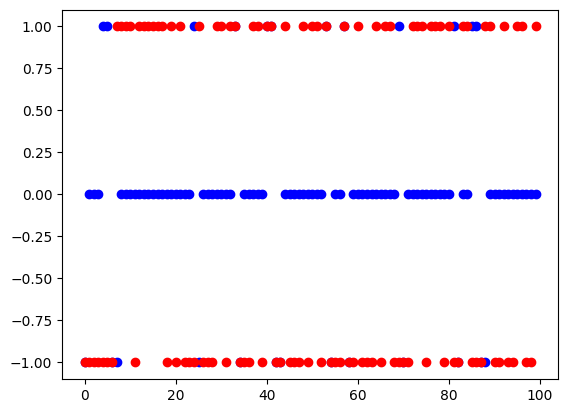

In [66]:
flag = 0
for i in range(len(final_sig)):
    if flag == 0:
        flag = final_sig[i]
    elif flag == final_sig[i] :
        final_sig[i] = 0
    elif flag == -final_sig[i]:
        flag = 0
    if i == len(final_sig) - 1:
        final_sig[i] = -flag
print(final_sig)
print(test_y)
plt.scatter(range(len(final_sig[:100])) , final_sig[:100] , c = 'b')
plt.scatter(range(len(final_sig[:100])) , test_y[:100] , c = 'r')
plt.show()

In [52]:
capital = 10000
price = data['close'].iloc[-len(final_sig):]
flag = 0
open = 0
for i in range(len(final_sig)):
    if flag:
        if final_sig[i] != 0:
            if final_sig[i] == -1:
                capital = capital*(price.values[i] - open)/open
            else:
                capital = capital*(open - price.values[i])/open
            flag = 0
    else:
        flag = 1
        open = price.values[i]
capital

-0.0

In [63]:
def returns(signals,timeseries):
    long=[]
    long_price=[]
    short_price=[]
    short=[]
    for i in range(len(signals)):
        if signals[i]==1:
            long.append(i)
            long_price.append(timeseries[i])
        elif signals[i]==-1:
            short.append(i)
            short_price.append(timeseries[i])
    cum_pnl=0
    while len(long)!=0 and len(short)!=0:
        if short[0]<long[0]:
            while short[0]<long[0]:
                cum_pnl+=(short_price[0]-long_price[0])*investment/short_price[0]-0.1/100*investment
                short.pop(0)
                short_price.pop(0)
                if len(short)==0 or len(long)==0:
                    break
            long.pop(0)
            long_price.pop(0) 

        elif long[0]<short[0]:
            while short[0]>long[0]:
                cum_pnl+=(short_price[0]-long_price[0])*investment/long_price[0]-0.1/100*investment
                long.pop(0)
                long_price.pop(0)
                if len(short)==0 or len(long)==0:
                    break
            short.pop(0)
            short_price.pop(0) 
            
    return cum_pnl

In [64]:
returns(final_sig , price)

KeyError: 0

In [68]:
pd.DataFrame(final_sig).to_csv('signals.csv' , index = False)

In [131]:
signal = np.where(pred >= 0.5 , 1 , -1)
signal

array([[ 1, -1, -1],
       [ 1, -1, -1],
       [ 1, -1, -1],
       ...,
       [ 1, -1, -1],
       [ 1, -1, -1],
       [ 1, -1, -1]])

In [132]:
flag = 0
print(type(signal[0][0]))
for i in range(len(signal)):
    if flag == 0:
        flag = signal[i][0]
    elif flag == signal[i][0] :
        signal[i][0] = 0
    elif flag == -signal[i][0]:
        flag = 0
    if i == len(signal) - 1:
        signal[i][0] = -flag
print(signal)

<class 'numpy.int32'>
[[ 1 -1 -1]
 [ 0 -1 -1]
 [ 0 -1 -1]
 ...
 [ 0 -1 -1]
 [ 0 -1 -1]
 [-1 -1 -1]]


In [133]:
model2 = Sequential()
model2.add(LSTM(100, input_shape=(train_X.shape[1], train_X.shape[2]), return_sequences=True))
model2.add(Dropout(0.2))  
model2.add(LSTM(100, return_sequences=True))
model2.add(Dropout(0.2))
model2.add(LSTM(100))
model2.add(Dense(512, activation='relu'))
model2.add(Dropout(0.5))
model2.add(Dense(3, activation='softmax'))  

optimizer = Adam(learning_rate=0.001)

model2.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model2.fit(train_X, train_y+1, epochs=100, batch_size=100, validation_data=(test_X, test_y+1), verbose=1, shuffle=False,callbacks=[early_stopping])

Epoch 1/100


KeyboardInterrupt: 

In [101]:
model2.evaluate(test_X , test_y+1)

220/220 [==============================] - 1s 3ms/step - loss: 0.6939 - accuracy: 0.4982


[0.693918764591217, 0.498153418302536]

In [90]:
pred2 = model2.predict(test_X)

220/220 [==============================] - 2s 3ms/step


In [93]:
pred2.min()

0.00013940826